In [ ]:
import os
print(os.listdir("data"))

['WhatsApp Image 2026-08-27 at 4.02.59 PM.jpeg']


ELA Function 

In [2]:
from PIL import Image, ImageChops
import numpy as np

def compute_ela(image_path, quality=90):
    original = Image.open(image_path).convert('RGB')
    
    # Save a recompressed version temporarily
    resaved_path = "temp_resaved.jpg"
    original.save(resaved_path, quality=quality)
    resaved = Image.open(resaved_path)
    
    # Compute pixel-wise difference
    diff = ImageChops.difference(original, resaved)
    diff_array = np.array(diff)
    
    # Amplify the difference so it's visible to the eye
    max_diff = diff_array.max() if diff_array.max() != 0 else 1
    scale = 255.0 / max_diff
    ela_image = Image.eval(diff, lambda x: min(255, x * scale))
    
    return ela_image, diff_array.mean()

ELA score(mean difference): 1.12484496124031


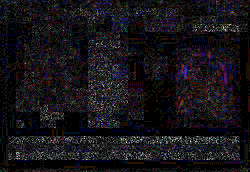

In [3]:
image_path = "data/WhatsApp Image 2026-08-27 at 4.02.59 PM.jpeg"
ela_result,score = compute_ela(image_path)

print("ELA score(mean difference):", score)
ela_result.save("outputs/ela_output.jpg")
ela_result

Mock Doc Generator

Saved to data/mock_passport.jpg


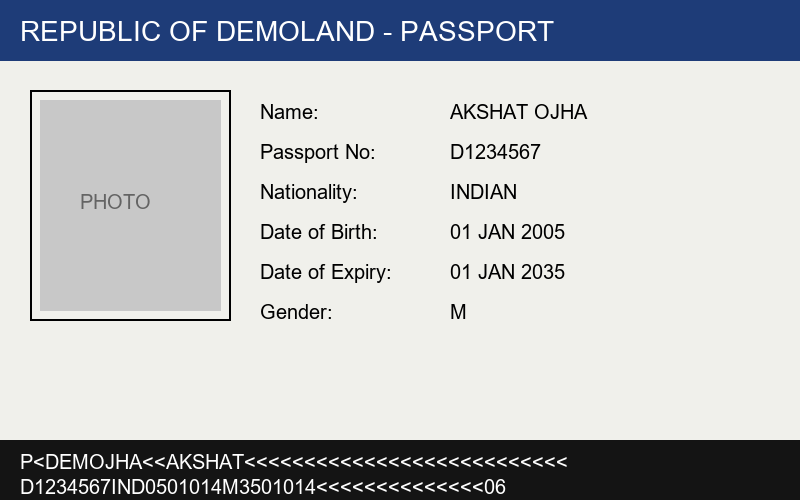

In [4]:
from PIL import Image, ImageDraw, ImageFont

def create_mock_document(save_path="data/mock_passport.jpg"):
    # Create a blank white canvas, passport-ish size
    img = Image.new('RGB', (800, 500), color=(240, 240, 235))
    draw = ImageDraw.Draw(img)
    
    # Try to use a basic font, fallback to default if unavailable
    try:
        font_large = ImageFont.truetype("arial.ttf", 28)
        font_small = ImageFont.truetype("arial.ttf", 20)
    except:
        font_large = ImageFont.load_default()
        font_small = ImageFont.load_default()
    
    # Header
    draw.rectangle([0, 0, 800, 60], fill=(30, 60, 120))
    draw.text((20, 15), "REPUBLIC OF DEMOLAND - PASSPORT", fill="white", font=font_large)
    
    # Photo placeholder box
    draw.rectangle([30, 90, 230, 320], outline="black", width=2)
    draw.rectangle([40, 100, 220, 310], fill=(200, 200, 200))
    draw.text((80, 190), "PHOTO", fill=(100, 100, 100), font=font_small)
    
    # Text fields
    fields = [
        ("Name:", "AKSHAT OJHA"),
        ("Passport No:", "D1234567"),
        ("Nationality:", "INDIAN"),
        ("Date of Birth:", "01 JAN 2005"),
        ("Date of Expiry:", "01 JAN 2035"),
        ("Gender:", "M"),
    ]
    
    y = 100
    for label, value in fields:
        draw.text((260, y), label, fill="black", font=font_small)
        draw.text((450, y), value, fill="black", font=font_small)
        y += 40
    
    # Fake MRZ lines at the bottom
    draw.rectangle([0, 440, 800, 500], fill=(20, 20, 20))
    draw.text((20, 450), "P<DEMOJHA<<AKSHAT<<<<<<<<<<<<<<<<<<<<<<<<<<<", fill="white", font=font_small)
    draw.text((20, 475), "D1234567IND0501014M3501014<<<<<<<<<<<<<<06", fill="white", font=font_small)
    
    img.save(save_path, quality=95)
    print(f"Saved to {save_path}")
    return img

mock_doc = create_mock_document()
mock_doc

Tampered Image Generator

Saved to data/mock_passport_tampered.jpg


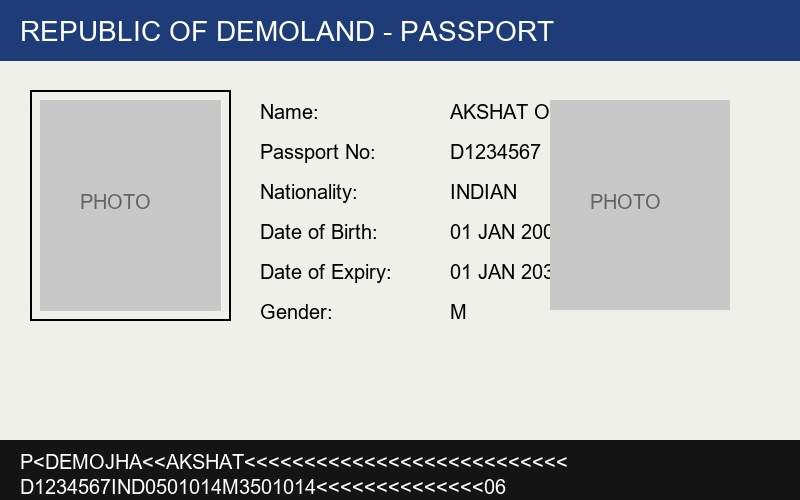

In [5]:
def create_tampered_document(original_path="data/mock_passport.jpg", save_path="data/mock_passport_tampered.jpg"):
    img = Image.open(original_path)
    
    region = img.crop((40, 100, 220, 310))
    img.paste(region, (550, 100))
    
    img.save(save_path, quality=95)
    print(f"Saved to {save_path}")
    return img

tampered_doc = create_tampered_document()
tampered_doc

In [6]:
ela_genuine, score_genuine = compute_ela("data/mock_passport.jpg")
ela_tampered, score_tampered = compute_ela("data/mock_passport_tampered.jpg")

print("Genuine ELA score:", score_genuine)
print("Tampered ELA score:", score_tampered)

Genuine ELA score: 0.5770125
Tampered ELA score: 0.6016066666666666


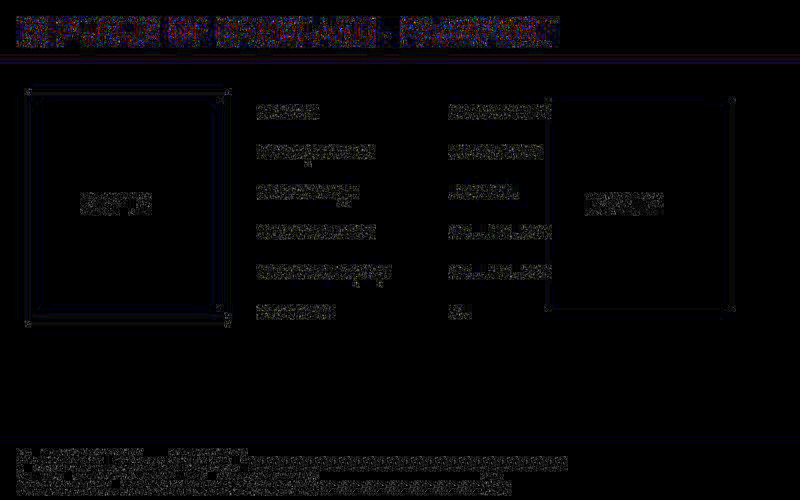

In [7]:
ela_tampered

Saved to data/mock_passport_tampered_v2.jpg


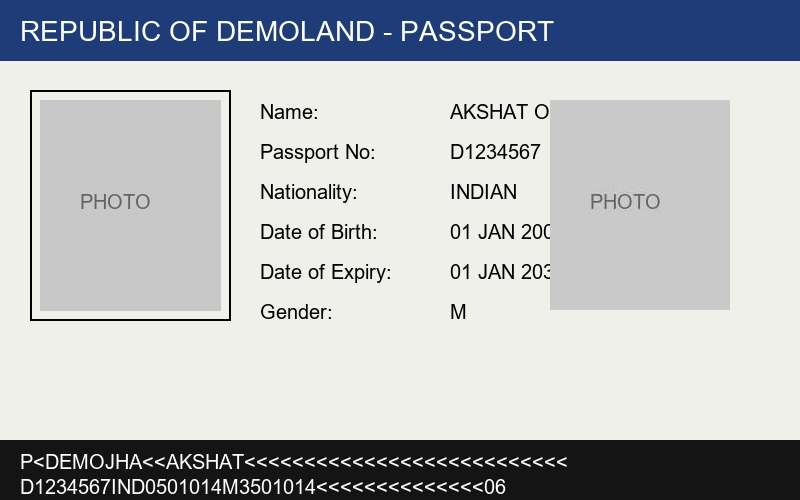

In [8]:
def create_tampered_document_v2(original_path="data/mock_passport.jpg", save_path="data/mock_passport_tampered_v2.jpg"):
    # Step 1: open the ORIGINAL genuine image (already compressed once when saved)
    img = Image.open(original_path)
    
    # Step 2: crop the photo region, save it separately (simulating it being edited elsewhere)
    region = img.crop((40, 100, 220, 310))
    region.save("temp_region.jpg", quality=70)  # different, lower quality — simulates re-editing
    
    # Step 3: reload that region (now it carries its own separate compression history)
    region_reloaded = Image.open("temp_region.jpg")
    
    # Step 4: paste it into the original and save at normal quality
    img.paste(region_reloaded, (550, 100))
    img.save(save_path, quality=95)
    
    print(f"Saved to {save_path}")
    return img

tampered_v2 = create_tampered_document_v2()
tampered_v2

Genuine ELA score: 0.5770125
Tampered v2 ELA score: 0.608475


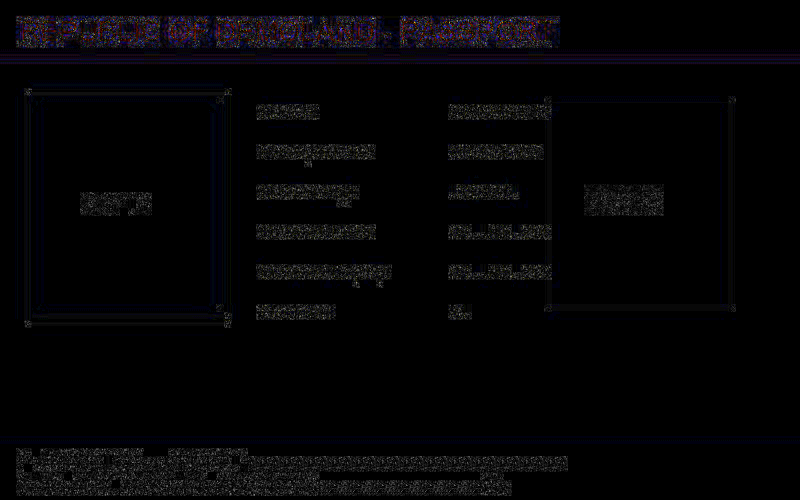

In [9]:
ela_tampered_v2, score_tampered_v2 = compute_ela("data/mock_passport_tampered_v2.jpg")
print("Genuine ELA score:", score_genuine)
print("Tampered v2 ELA score:", score_tampered_v2)
ela_tampered_v2

In [10]:
def compute_ela_v2(image_path, quality=90, scale_factor=15):
    original = Image.open(image_path).convert('RGB')
    
    resaved_path = "temp_resaved.jpg"
    original.save(resaved_path, quality=quality)
    resaved = Image.open(resaved_path)
    
    diff = ImageChops.difference(original, resaved)
    diff_array = np.array(diff)
    
    # Fixed scale instead of dynamic max-based scale
    ela_image = Image.eval(diff, lambda x: min(255, x * scale_factor))
    
    return ela_image, diff_array.mean()

Final Heatmap

Genuine v2: 0.5770125
Tampered v2b: 0.608475


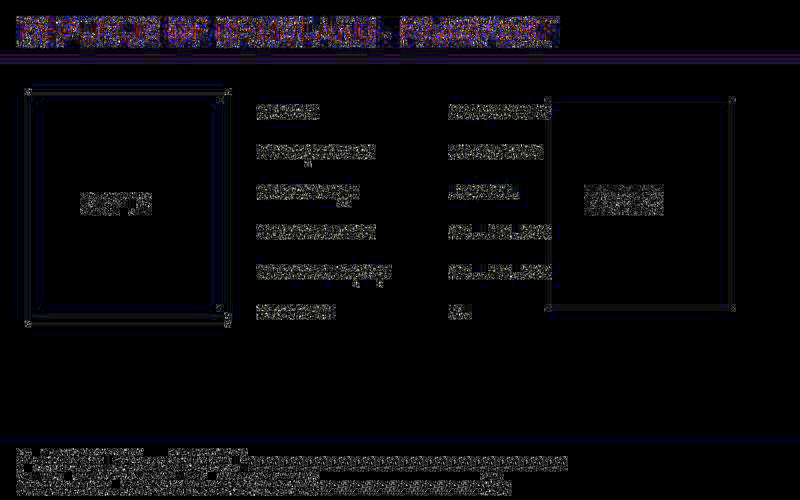

In [11]:
ela_genuine_v2, score_genuine_v2 = compute_ela_v2("data/mock_passport.jpg")
ela_tampered_v2b, score_tampered_v2b = compute_ela_v2("data/mock_passport_tampered_v2.jpg")

print("Genuine v2:", score_genuine_v2)
print("Tampered v2b:", score_tampered_v2b)
ela_tampered_v2b

In [12]:
def analyze_region(diff_array, box):
    # box = (left, top, right, bottom)
    left, top, right, bottom = box
    region = diff_array[top:bottom, left:right]
    return region.mean()

# Reload the raw diff arrays
def get_diff_array(image_path, quality=90):
    original = Image.open(image_path).convert('RGB')
    original.save("temp_resaved.jpg", quality=quality)
    resaved = Image.open("temp_resaved.jpg")
    diff = ImageChops.difference(original, resaved)
    return np.array(diff)

diff_genuine = get_diff_array("data/mock_passport.jpg")
diff_tampered = get_diff_array("data/mock_passport_tampered_v2.jpg")

# Original photo box region: (40, 100, 220, 310)
# Pasted duplicate region: (550, 100, 730, 310)

print("Genuine — original photo box region avg diff:", analyze_region(diff_genuine, (40, 100, 220, 310)))
print("Tampered — original photo box region avg diff:", analyze_region(diff_tampered, (40, 100, 220, 310)))
print("Tampered — PASTED duplicate region avg diff:", analyze_region(diff_tampered, (550, 100, 730, 310)))
print("Genuine — SAME coordinates (550,100,730,310) but empty area avg diff:", analyze_region(diff_genuine, (550, 100, 730, 310)))

Genuine — original photo box region avg diff: 0.18156084656084656
Tampered — original photo box region avg diff: 0.1815079365079365
Tampered — PASTED duplicate region avg diff: 0.25785714285714284
Genuine — SAME coordinates (550,100,730,310) but empty area avg diff: 0.10423280423280423


In [13]:
def ela_tamper_score(image_path, quality=90):
    diff_array = get_diff_array(image_path, quality)
    overall_score = diff_array.mean()
    max_local_score = diff_array.max()  # catches localized spikes even if overall mean is low
    return overall_score, max_local_score

score_genuine, max_genuine = ela_tamper_score("data/mock_passport.jpg")
score_tampered, max_tampered = ela_tamper_score("data/mock_passport_tampered_v2.jpg")

print("Genuine — mean:", score_genuine, "| max:", max_genuine)
print("Tampered — mean:", score_tampered, "| max:", max_tampered)

Genuine — mean: 0.5770125 | max: 32
Tampered — mean: 0.608475 | max: 32


In [14]:
def ela_sliding_window_score(image_path, quality=90, window_size=60, stride=30):
    diff_array = get_diff_array(image_path, quality)
    h, w, _ = diff_array.shape
    
    max_region_score = 0
    for y in range(0, h - window_size, stride):
        for x in range(0, w - window_size, stride):
            region = diff_array[y:y+window_size, x:x+window_size]
            region_score = region.mean()
            if region_score > max_region_score:
                max_region_score = region_score
    
    return max_region_score

score_genuine_sw = ela_sliding_window_score("data/mock_passport.jpg")
score_tampered_sw = ela_sliding_window_score("data/mock_passport_tampered_v2.jpg")

print("Genuine — max region score (sliding window):", score_genuine_sw)
print("Tampered — max region score (sliding window):", score_tampered_sw)

Genuine — max region score (sliding window): 2.6725
Tampered — max region score (sliding window): 2.655925925925926


In [15]:
def ela_diff_from_baseline(genuine_path, suspect_path, quality=90, window_size=60, stride=30):
    diff_genuine = get_diff_array(genuine_path, quality)
    diff_suspect = get_diff_array(suspect_path, quality)
    
    h, w, _ = diff_genuine.shape
    
    max_discrepancy = 0
    max_location = None
    
    for y in range(0, h - window_size, stride):
        for x in range(0, w - window_size, stride):
            region_genuine = diff_genuine[y:y+window_size, x:x+window_size].mean()
            region_suspect = diff_suspect[y:y+window_size, x:x+window_size].mean()
            
            discrepancy = region_suspect - region_genuine
            
            if discrepancy > max_discrepancy:
                max_discrepancy = discrepancy
                max_location = (x, y)
    
    return max_discrepancy, max_location

discrepancy, location = ela_diff_from_baseline("data/mock_passport.jpg", "data/mock_passport_tampered_v2.jpg")
print("Max discrepancy vs baseline:", discrepancy)
print("Location (x, y):", location)

Max discrepancy vs baseline: 1.481111111111111
Location (x, y): (600, 180)


## Day 2 Notes — Error Level Analysis (ELA) for Tamper Detection

**What ELA does:**
Re-saves the image at a known JPEG quality and computes the pixel-wise 
difference against the original. Regions edited/re-saved separately from 
the rest of the image show a different compression pattern, causing a 
higher difference — this reveals possible tampering.

**Key findings from testing:**
- Naive whole-image `mean()` or `max()` score get 
  dominated by high-contrast text/edges, which produce large ELA 
  differences even in genuine, untouched documents.
- Regional/localized analysis (comparing small windows/patches instead 
  of the whole image at once) is needed to isolate real tampering from 
  normal text-edge noise.
- Tested with a synthetic mock passport: pasted-region ELA score was 
  ~2.5x higher than the same coordinates in the genuine image 
  (0.258 vs 0.104).
- Baseline-comparison method (diffing suspect image against its known 
  genuine version) correctly localized the tampered region to within 
  the exact pasted coordinates.

**Limitation to remember:**
- ELA only works on JPEG (lossy compression) — not PNG.
- Baseline comparison (used for validation here) isn't available for 
  real unknown documents in production — the deployed pipeline will use 
  absolute thresholds tuned on a genuine-document dataset instead of 
  diffing against a known-good copy.